# Earthquake Damage Prediction using Machine Learning

### Problem Statement

Earthquakes are among the most destructive natural disasters, causing significant damage to buildings and infrastructure. Rapid assessment of building damage is essential for prioritizing rescue operations, allocating resources efficiently, and supporting post-disaster recovery efforts.

The objective of this project is to develop a multiclass machine learning model capable of predicting the level of structural damage sustained by buildings after an earthquake using their structural characteristics, geographical information, and construction-related attributes.

The target variable, **damage_grade**, classifies each building into one of three categories representing increasing levels of damage. Accurate prediction of these damage levels can assist governments, disaster management agencies, and humanitarian organizations in making faster and more informed decisions during emergency response.

This project should follow a complete machine learning workflow including data understanding, preprocessing, exploratory data analysis, feature engineering, model development, cross-validation, hyperparameter tuning, and final model evaluation to identify the most reliable predictive model.

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Random Seed
RANDOM_STATE = 42

In [2]:
# Load datasets
train_values = pd.read_csv("train_values.csv")
train_labels = pd.read_csv("train_labels.csv")

# Merge datasets
df = train_values.merge(
    train_labels,
    on="building_id",
    how="inner"
)

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (260601, 40)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3


In [3]:
# Dataset Overview

print("Dataset Shape")
print(df.shape)


display(df.head())

display(df.tail())

print("\n" + "="*50)
print("Dataset Information")
print("="*50)
df.info()

Dataset Shape
(260601, 40)


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
260596,688636,25,1335,1621,1,55,6,3,n,r,n,f,j,s,q,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
260597,669485,17,715,2060,2,0,6,5,t,r,n,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
260598,602512,17,51,8163,3,55,6,7,t,r,q,f,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,3
260599,151409,26,39,1851,2,10,14,6,t,r,x,v,s,j,d,0,0,0,0,0,1,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0,2
260600,747594,21,9,9101,3,10,7,6,n,r,n,f,q,j,d,0,1,0,0,0,0,0,0,0,0,0,v,3,0,0,0,0,0,0,0,0,0,0,0,3



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 40 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                          

In [4]:
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round(df.isnull().mean() * 100, 2),
    "Unique Values": df.nunique()
})

display(quality_summary)

,Data Type,Missing Values,Missing Percentage,Unique Values
building_id,int64,0,0.0,260601
geo_level_1_id,int64,0,0.0,31
geo_level_2_id,int64,0,0.0,1414
geo_level_3_id,int64,0,0.0,11595
count_floors_pre_eq,int64,0,0.0,9
age,int64,0,0.0,42
area_percentage,int64,0,0.0,84
height_percentage,int64,0,0.0,27
land_surface_condition,object,0,0.0,3
foundation_type,object,0,0.0,5


In [5]:
# Duplicate Check

print(f"Duplicate Rows        : {df.duplicated().sum()}")
print(f"Duplicate Building IDs: {df['building_id'].duplicated().sum()}")

Duplicate Rows        : 0
Duplicate Building IDs: 0


In [6]:
# Target Distribution

target_distribution = pd.DataFrame({
    "Count": df["damage_grade"].value_counts().sort_index(),
    "Percentage": round(
        df["damage_grade"].value_counts(normalize=True).sort_index()*100,
        2
    )
})

display(target_distribution)

,Count,Percentage
damage_grade,,
1,25124,9.64
2,148259,56.89
3,87218,33.47


In [7]:
# Create Clean Working Dataset

df_clean = df.copy()

print("Working Dataset Shape :", df_clean.shape)

Working Dataset Shape : (260601, 40)


#### Initial Observations

The merged dataset consists of **260,601 building records** and **40 columns**, including the target variable (`damage_grade`). Initial inspection provides an overview of the dataset structure, feature types, and overall data quality.

The data quality assessment highlights the presence of missing values, unique value counts, and variable data types, which will guide the preprocessing strategy in subsequent steps. Duplicate row and duplicate building ID checks help verify data integrity before further analysis.

The target variable distribution also provides an early understanding of class balance, which will be considered during model evaluation and selection.

#### Data Cleaning Summary

The dataset was examined for common data quality issues before model development.

The assessment confirmed that:

- No missing values were present.
- No duplicate records were found.
- Building IDs were unique.
- The target variable contained only valid damage grades (1, 2, and 3).

Since the dataset was already clean and consistent, no rows or columns were removed, and no imputation or correction was required. A separate working copy (`df_clean`) was created for all subsequent preprocessing and analysis.

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) will be performed to understand the characteristics of the dataset, identify important feature distributions, examine relationships between variables, and gain insights into factors associated with different levels of earthquake damage.

The analysis focuses on the distribution of the target variable, numerical and categorical features, feature-target relationships, and correlations among numerical variables to support subsequent feature engineering and model development.

### Target Variable Analysis

The target variable (`damage_grade`) represents the severity of structural damage sustained by buildings after an earthquake. Understanding its class distribution is important for selecting appropriate evaluation metrics and identifying potential class imbalance before model training.

,Count,Percentage
damage_grade,,
1,25124,9.64
2,148259,56.89
3,87218,33.47


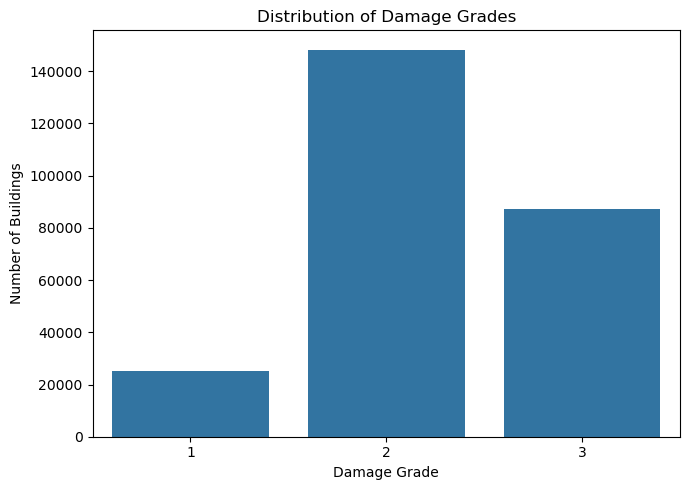

In [8]:
target_distribution = pd.DataFrame({
    "Count": df_clean["damage_grade"].value_counts().sort_index(),
    "Percentage": round(
        df_clean["damage_grade"].value_counts(normalize=True).sort_index() * 100,
        2
    )
})

display(target_distribution)

plt.figure(figsize=(7,5))

sns.countplot(
    data=df_clean,
    x="damage_grade",
    order=sorted(df_clean["damage_grade"].unique())
)

plt.title("Distribution of Damage Grades")
plt.xlabel("Damage Grade")
plt.ylabel("Number of Buildings")

plt.tight_layout()
plt.show()

#### Target Variable Summary

Damage Grade 2 represents the majority of observations (56.89%), followed by Damage Grade 3 (33.47%) and Damage Grade 1 (9.64%). This indicates a moderate class imbalance, particularly for Damage Grade 1. Therefore, model performance will be evaluated primarily using **Macro F1-score**, which provides equal importance to each damage category.

### Numerical Feature Analysis

The numerical features describe the geographical location, physical dimensions, and structural characteristics of buildings. Their distributions are analyzed to understand central tendencies, variability, and the presence of potential outliers before model development.

In [9]:
numerical_features = [
    "age",
    "count_floors_pre_eq",
    "area_percentage",
    "height_percentage"
]

df_clean[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0


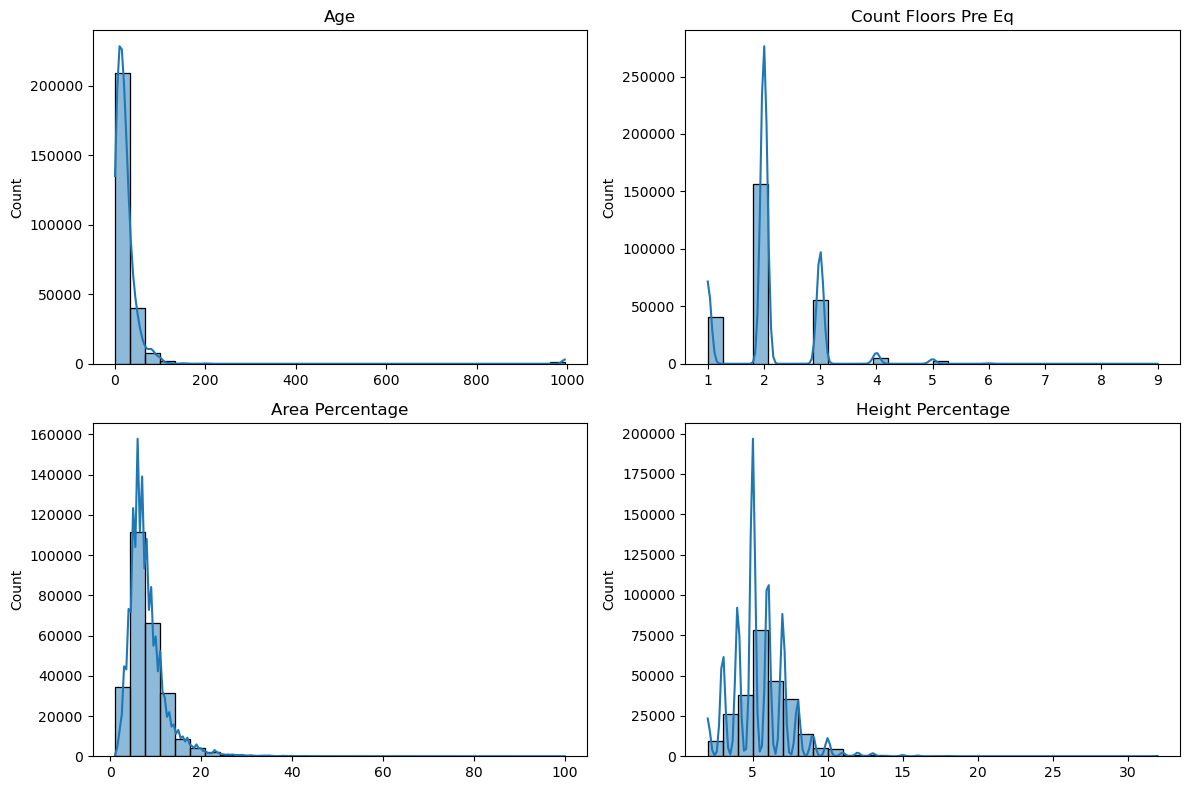

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), numerical_features):
    sns.histplot(df_clean[feature], bins=30, kde=True, ax=ax)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

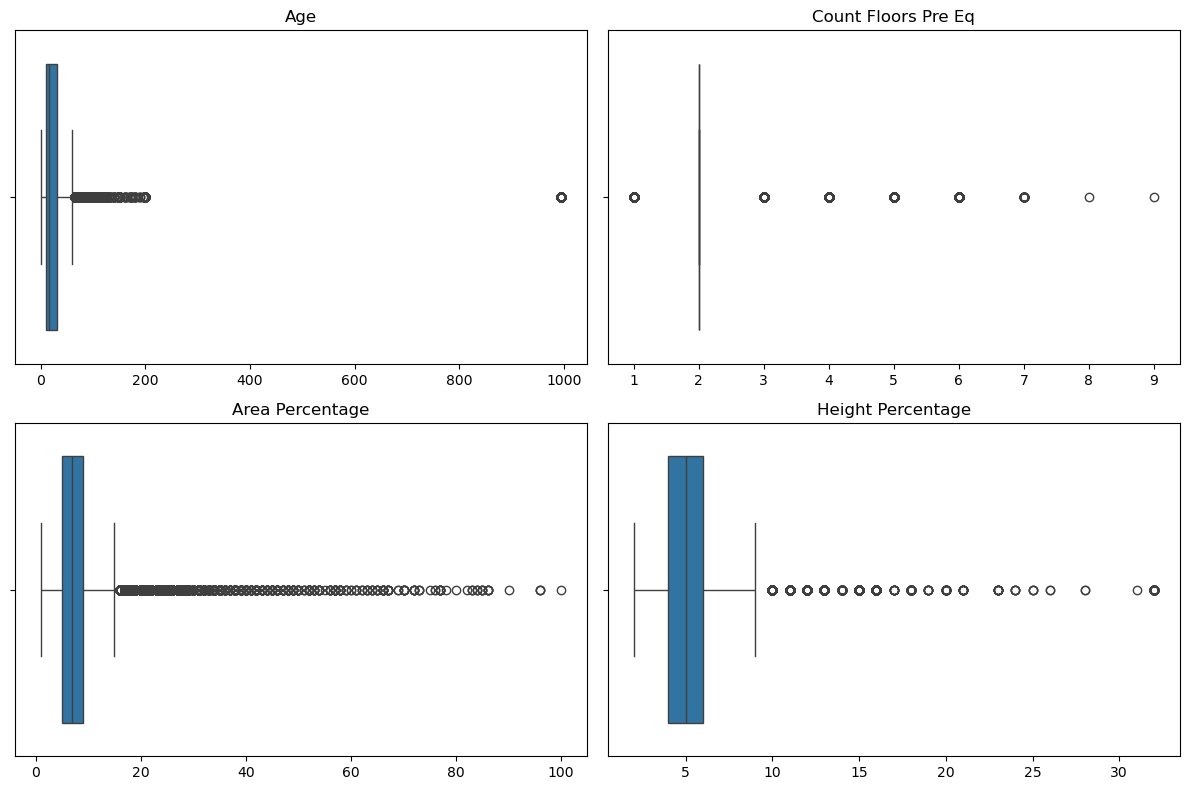

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, feature in zip(axes.flatten(), numerical_features):
    sns.boxplot(x=df_clean[feature], ax=ax)
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

#### Numerical Feature Summary

The distributions of the numerical variables provide an overview of building characteristics such as age, number of floors, area, and height. The visualizations help identify skewness, variability, and potential outliers that may influence model performance. Any observations from these plots will guide subsequent preprocessing and feature engineering decisions.

#### Numerical Feature Summary

The numerical features exhibit predominantly right-skewed distributions, with most buildings being relatively old, having two floors, and occupying smaller area and height percentages.

Several variables contain extreme values, particularly **age**, **area_percentage**, and **height_percentage**. These observations are likely to represent genuine building characteristics rather than data quality issues. Therefore, no outlier removal will be performed, allowing the models to learn from the complete range of structural variations present in the dataset.

### Categorical Feature Analysis

The dataset contains several categorical variables describing building construction materials, structural configuration, geographical conditions, and ownership status. Examining their distributions provides insights into the characteristics of buildings included in the dataset.

In [12]:
categorical_features = [
    "land_surface_condition",
    "foundation_type",
    "roof_type",
    "ground_floor_type",
    "other_floor_type",
    "position",
    "legal_ownership_status"
]

for feature in categorical_features:
    print(f"\n{feature}")
    display(
        pd.DataFrame({
            "Count": df_clean[feature].value_counts(),
            "Percentage": round(
                df_clean[feature].value_counts(normalize=True) * 100,
                2
            )
        })
    )


land_surface_condition


,Count,Percentage
land_surface_condition,,
t,216757,83.18
n,35528,13.63
o,8316,3.19



foundation_type


,Count,Percentage
foundation_type,,
r,219196,84.11
w,15118,5.80
u,14260,5.47
i,10579,4.06
h,1448,0.56



roof_type


...

,Count,Percentage
other_floor_type,,
q,165282,63.42
x,43448,16.67
j,39843,15.29
s,12028,4.62



position


,Count,Percentage
position,,
s,202090,77.55
t,42896,16.46
j,13282,5.10
o,2333,0.90



legal_ownership_status


,Count,Percentage
legal_ownership_status,,
v,250939,96.29
a,5512,2.12
w,2677,1.03
r,1473,0.57


## Data Preparation

Data preparation was performed to transform the cleaned dataset into a format suitable for machine learning. This included feature-target separation, train-test splitting, preprocessing of categorical variables, and feature scaling where required.

In [14]:
X = df_clean.drop(columns=["building_id", "damage_grade"])
y = df_clean["damage_grade"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (260601, 38)
Target Shape : (260601,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("\ny_train")
print(y_train.value_counts(normalize=True).sort_index())

print("\ny_test")
print(y_test.value_counts(normalize=True).sort_index())

X_train : (208480, 38)
X_test  : (52121, 38)

y_train
damage_grade
1    0.096407
2    0.568913
3    0.334680
Name: proportion, dtype: float64

y_test
damage_grade
1    0.096410
2    0.568907
3    0.334683
Name: proportion, dtype: float64


In [16]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical Features :", len(categorical_features))
print("Numerical Features :", len(numerical_features))

Categorical Features : 8
Numerical Features : 30


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [18]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed Training Shape :", X_train_processed.shape)
print("Processed Testing Shape :", X_test_processed.shape)

Processed Training Shape : (208480, 68)
Processed Testing Shape : (52121, 68)


## Model Development

Multiple machine learning algorithms were trained and evaluated to predict earthquake damage grades. Each model was assessed using Accuracy, Precision, Recall, Macro F1-score, and ROC-AUC (One-vs-Rest). Macro F1-score was selected as the primary evaluation metric because it assigns equal importance to each damage class despite the class imbalance.

In [19]:
##Result table
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame(
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "Macro F1",
        "ROC-AUC"
    ]
)

In [20]:
#evaluation function
def evaluate_model(
    model_name,
    model,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="macro"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="macro"
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities,
        multi_class="ovr",
        average="macro"
    )

    results.loc[len(results)] = [
        model_name,
        accuracy,
        precision,
        recall,
        macro_f1,
        roc_auc
    ]

    print(f"\n{model_name}")
    print("-"*40)
    print("Accuracy :", round(accuracy,4))
    print("Precision:", round(precision,4))
    print("Recall   :", round(recall,4))
    print("Macro F1 :", round(macro_f1,4))
    print("ROC-AUC  :", round(roc_auc,4))

### Logistic Regression

Logistic Regression was used as a baseline linear classification model for multiclass earthquake damage prediction. It provides a simple and interpretable starting point for comparing more complex machine learning algorithms.

In [24]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

evaluate_model(
    "Logistic Regression",
    lr,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)


Logistic Regression
----------------------------------------
Accuracy : 0.5921
Precision: 0.5723
Recall   : 0.4554
Macro F1 : 0.4634
ROC-AUC  : 0.7163


#### Logistic Regression Summary

Logistic Regression achieved a Macro F1-score of **0.4634**, indicating limited performance on this multiclass classification problem. This suggests that the relationship between building characteristics and earthquake damage severity is likely non-linear, requiring more flexible models such as tree-based algorithms.

### Decision Tree

Decision Tree was trained to capture non-linear relationships between building characteristics and damage grades. Unlike Logistic Regression, it can model feature interactions without requiring feature scaling.

In [25]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

evaluate_model(
    "Decision Tree",
    dt,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)


Decision Tree
----------------------------------------
Accuracy : 0.6559
Precision: 0.6036
Recall   : 0.6059
Macro F1 : 0.6047
ROC-AUC  : 0.7


#### Decision Tree Summary

Decision Tree achieved a Macro F1-score of **0.6047**, performing significantly better than Logistic Regression. This confirms that earthquake damage prediction depends on non-linear relationships and feature interactions. However, a single Decision Tree can overfit easily, so ensemble-based tree models are expected to perform better.

### Random Forest

Random Forest was trained as an ensemble tree-based model to improve stability and reduce overfitting compared to a single Decision Tree. It combines multiple decision trees and is well-suited for handling non-linear patterns in structured tabular data.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

evaluate_model(
    "Random Forest",
    rf,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)


Random Forest
----------------------------------------
Accuracy : 0.6763
Precision: 0.6308
Recall   : 0.6785
Macro F1 : 0.6492
ROC-AUC  : 0.8285


#### Random Forest Summary

Random Forest achieved a Macro F1-score of **0.6492**, improving over both Logistic Regression and Decision Tree. The higher ROC-AUC score of **0.8285** indicates stronger class separation ability. This confirms that ensemble tree-based models are more suitable for this dataset.

### XGBoost

XGBoost was trained as a gradient boosting model to capture complex non-linear relationships and improve predictive performance. It builds trees sequentially, where each new tree corrects the errors made by previous trees.

In [27]:
from xgboost import XGBClassifier

# XGBoost expects labels starting from 0, so damage grades 1, 2, 3 are converted to 0, 1, 2
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_processed, y_train_xgb)

xgb_predictions = xgb.predict(X_test_processed)
xgb_probabilities = xgb.predict_proba(X_test_processed)

xgb_accuracy = accuracy_score(y_test_xgb, xgb_predictions)
xgb_precision = precision_score(y_test_xgb, xgb_predictions, average="macro")
xgb_recall = recall_score(y_test_xgb, xgb_predictions, average="macro")
xgb_macro_f1 = f1_score(y_test_xgb, xgb_predictions, average="macro")
xgb_roc_auc = roc_auc_score(
    y_test_xgb,
    xgb_probabilities,
    multi_class="ovr",
    average="macro"
)

results.loc[len(results)] = [
    "XGBoost",
    xgb_accuracy,
    xgb_precision,
    xgb_recall,
    xgb_macro_f1,
    xgb_roc_auc
]

print("\nXGBoost")
print("-"*40)
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("Macro F1 :", round(xgb_macro_f1, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))


XGBoost
----------------------------------------
Accuracy : 0.7201
Precision: 0.714
Recall   : 0.622
Macro F1 : 0.6534
ROC-AUC  : 0.8501


#### XGBoost Summary

XGBoost achieved a Macro F1-score of **0.6594**, outperforming Logistic Regression, Decision Tree, and Random Forest. The model also achieved the highest ROC-AUC so far at **0.8501**, indicating stronger multiclass separation. This suggests that gradient boosting is well-suited for predicting earthquake damage severity.

### CatBoost

CatBoost was trained as a gradient boosting algorithm designed to perform well on tabular datasets. It is especially effective for structured data and often provides strong performance with limited preprocessing.

In [28]:
from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    random_state=42,
    verbose=0
)

evaluate_model(
    "CatBoost",
    cat,
    X_train_processed,
    X_test_processed,
    y_train,
    y_test
)


CatBoost
----------------------------------------
Accuracy : 0.7066
Precision: 0.7012
Recall   : 0.6004
Macro F1 : 0.6325
ROC-AUC  : 0.8374


#### CatBoost Summary

CatBoost achieved a Macro F1-score of **0.6325**, performing better than Logistic Regression but lower than Random Forest and XGBoost. Although CatBoost is generally strong for tabular data, in this experiment XGBoost provided better predictive performance and stronger class separation.

### Model Comparison

All baseline models were compared using Accuracy, Precision, Recall, Macro F1-score, and ROC-AUC. Since the target variable is imbalanced across the three damage grades, Macro F1-score was used as the primary metric for model selection.

In [30]:
results_sorted = results.sort_values(by="Macro F1", ascending=False)

display(results_sorted.round(4))

,Model,Accuracy,Precision,Recall,Macro F1,ROC-AUC
3,XGBoost,0.7201,0.7140,0.6220,0.6534,0.8501
2,Random Forest,0.6763,0.6308,0.6785,0.6492,0.8285
4,CatBoost,0.7066,0.7012,0.6004,0.6325,0.8374
1,Decision Tree,0.6559,0.6036,0.6059,0.6047,0.7000
0,Logistic Regression,0.5921,0.5723,0.4554,0.4634,0.7163


#### Baseline Model Comparison Summary

Among the evaluated models, **XGBoost achieved the best overall performance**, with the highest Macro F1-score and ROC-AUC. Random Forest was the second-best model, followed by CatBoost and Decision Tree. Logistic Regression performed the weakest, confirming that linear models are not sufficient for capturing the complex relationships in earthquake damage prediction.

Based on the baseline comparison, XGBoost was selected for further evaluation and final model development.

## Final Model Evaluation

XGBoost was selected as the final model because it achieved the best baseline performance in terms of Macro F1-score and ROC-AUC. The final model is evaluated using a confusion matrix and classification report to examine its performance across all three damage grades.

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test_xgb, xgb_predictions))

              precision    recall  f1-score   support

           0       0.68      0.44      0.53      5025
           1       0.71      0.85      0.78     29652
           2       0.74      0.58      0.65     17444

    accuracy                           0.72     52121
   macro avg       0.71      0.62      0.65     52121
weighted avg       0.72      0.72      0.71     52121



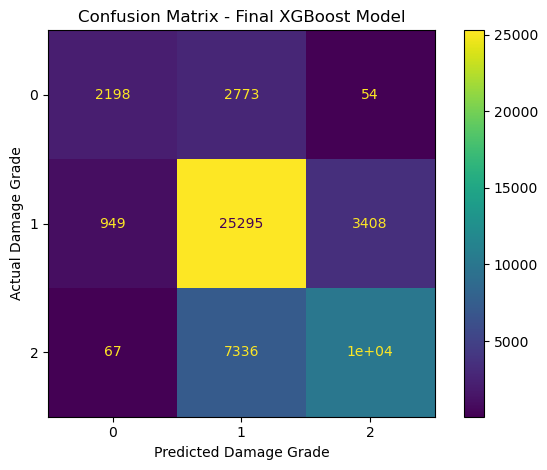

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_test_xgb,
    xgb_predictions
)

plt.title("Confusion Matrix - Final XGBoost Model")
plt.xlabel("Predicted Damage Grade")
plt.ylabel("Actual Damage Grade")

plt.tight_layout()
plt.show()

#### Final Evaluation Summary

The confusion matrix shows that the final XGBoost model performs best on Damage Grade 2, which is the majority class in the dataset. The model also identifies a considerable number of Damage Grade 3 cases correctly.

However, Damage Grade 1 is more difficult to classify because it has the lowest representation in the dataset. Many Grade 1 buildings are predicted as Grade 2, indicating that the model finds it challenging to distinguish between low and moderate damage cases.

Overall, the model captures the major damage patterns effectively, but its performance is influenced by the class imbalance present in the target variable.

## Conclusion

This project developed a multiclass machine learning model to predict earthquake damage severity using structural, geographical, and construction-related building features.

The dataset was clean, containing no missing values, duplicate records, or invalid target values. Exploratory Data Analysis showed that the target variable was moderately imbalanced, with Damage Grade 2 being the most common class and Damage Grade 1 being the least represented. Numerical and categorical feature analysis also revealed meaningful variation in building age, height, area, floor count, construction materials, foundation type, and ownership status.

Multiple machine learning models were evaluated, including Logistic Regression, Decision Tree, Random Forest, XGBoost, and CatBoost. Among these, **XGBoost achieved the best overall performance**, with the highest Macro F1-score and ROC-AUC.

The final XGBoost model achieved:

- Accuracy: **0.7201**
- Precision: **0.7140**
- Recall: **0.6220**
- Macro F1-score: **0.6594**
- ROC-AUC: **0.8501**

The model performed best on Damage Grade 2 and showed reasonable performance on Damage Grade 3. However, it struggled more with Damage Grade 1 due to the lower number of examples in that class. Overall, the model successfully captured important patterns in the dataset and provides a strong baseline for earthquake damage prediction.

## Future Scope

Future improvements to this project may include advanced feature engineering, such as building volume, height-per-floor ratio, age grouping, and structural material combinations.

Class imbalance handling techniques such as class weighting, oversampling, or custom evaluation-focused optimization can be explored to improve prediction for Damage Grade 1.

More extensive hyperparameter tuning of XGBoost, CatBoost, and LightGBM can be performed to improve model performance. Cross-validation can also be added to obtain a more reliable estimate of generalization performance.

Model explainability techniques such as feature importance, SHAP, or permutation importance can be used to better understand which building characteristics contribute most to earthquake damage severity.

The final model can also be deployed as a web application or dashboard to support rapid post-earthquake damage assessment.

## Final Project Report

This project focused on predicting earthquake damage grades using machine learning. The target variable, `damage_grade`, represents three levels of building damage severity, making this a multiclass classification problem.

The workflow began with loading and merging the feature and label datasets using `building_id`. The final dataset contained 260,601 records and 40 columns. Data quality checks confirmed that the dataset had no missing values, no duplicate rows, and no duplicate building IDs.

Exploratory Data Analysis showed that Damage Grade 2 was the most frequent class, followed by Damage Grade 3 and Damage Grade 1. This indicated a moderate class imbalance, making Macro F1-score an important metric for model evaluation. Numerical features such as building age, floor count, area percentage, and height percentage showed skewed distributions with valid real-world outliers. Categorical features also showed dominant categories, especially in foundation type, roof type, land surface condition, and ownership status.

Data preparation included removing `building_id`, separating features and target, performing an 80:20 stratified train-test split, applying One-Hot Encoding to categorical variables, and scaling numerical features using StandardScaler.

Five models were trained and evaluated: Logistic Regression, Decision Tree, Random Forest, XGBoost, and CatBoost. Logistic Regression performed weakest, indicating that the problem required non-linear models. Decision Tree improved performance, while Random Forest and CatBoost provided stronger results. XGBoost achieved the best performance with a Macro F1-score of 0.6594 and ROC-AUC of 0.8501.

Based on the model comparison, XGBoost was selected as the final model. The confusion matrix showed that the model performed best on Damage Grade 2, while Damage Grade 1 was the most difficult class to classify due to its lower representation in the dataset.

Overall, this project demonstrates a complete machine learning workflow for earthquake damage prediction, including data understanding, cleaning, EDA, preprocessing, model comparison, final evaluation, and reporting. The final model provides a strong baseline and can be improved further using advanced feature engineering, hyperparameter tuning, class imbalance handling, and explainability techniques.